In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

In [2]:
df_da_us = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

In [5]:
df_da_us = df_da_us.dropna(subset=['salary_year_avg'])

<Axes: >

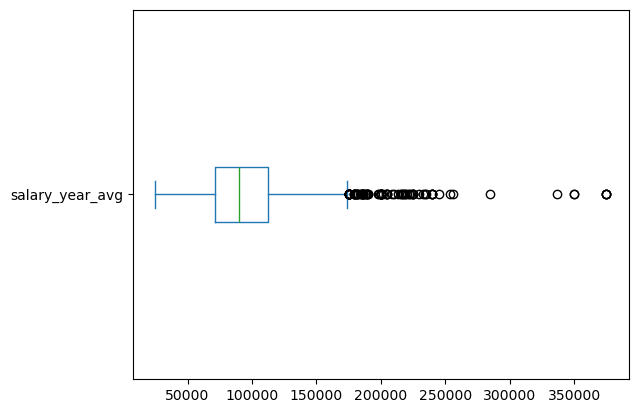

In [7]:
df_da_us['salary_year_avg'].plot(kind='box', vert=False)

C:\Users\SHARATSAI\AppData\Local\Temp\ipykernel_34896\2200127404.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  job_list = [df_us[df['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]
C:\Users\SHARATSAI\AppData\Local\Temp\ipykernel_34896\2200127404.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  job_list = [df_us[df['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]
C:\Users\SHARATSAI\AppData\Local\Temp\ipykernel_34896\2200127404.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  job_list = [df_us[df['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]


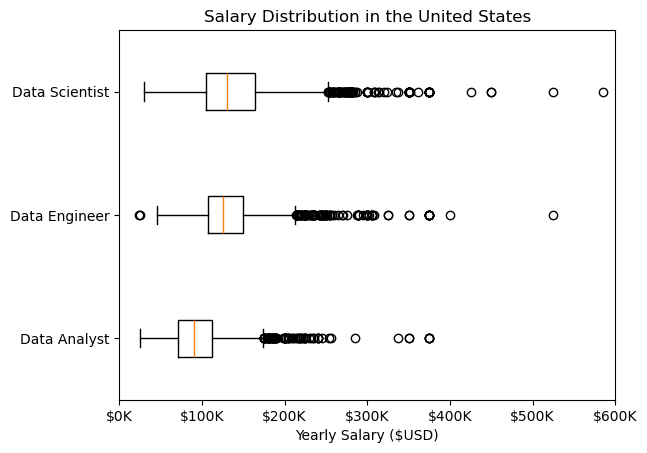

In [16]:
job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']

df_us = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()
df_us = df_us.dropna(subset=['salary_year_avg'])

job_list = [df_us[df['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]

plt.boxplot(job_list, tick_labels=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
plt.ylabel('')
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.xlim(0, 600000)
plt.show()